## Data Preparation

**Muskv2** https://archive.ics.uci.edu/dataset/75/musk+version+2
This dataset describes a set of 102 molecules of which 39 are judged by human experts to be musks and the remaining 63 molecules are judged to be non-musks.  The goal is to learn to predict whether new molecules will be musks or non-musks.  

**Gallstones** https://archive.ics.uci.edu/dataset/1150/gallstone-1  The clinical dataset was collected from the Internal Medicine Outpatient Clinic of Ankara VM Medical Park Hospital and includes data from 319 individuals (June 2022–June 2023), 161 of whom were diagnosed with gallstone disease. It contains 38 features, including demographic, bioimpedance, and laboratory data, and was ethically approved by the Ankara City Hospital Ethics Committee (E2-23-4632).

**Spectrometer** 
http://archive.ics.uci.edu/dataset/93/low+resolution+spectrometer 
This database contains 531 high quality spectra derived from the IRAS-LRS database.  The original data contained 100 spectral measurements in each of two overlapping bands.  Of these, 44 blue band and 49 red band channels contain usable flux measurements.  Only these are included here.  The original spectral intensities values are compressed to 4-digits, and each spectrum includes 5 rescaling parameters. Originally, LRS-class: integer - The LRS-class values range from 0 - 99 with the 10's digit giving the basic class and the 1's digit giving the subclass. These classes are based on features (peaks, valleys, and trends) of the spectral curves.

https://www.openml.org/search?type=data&sort=runs&status=active&qualities.NumberOfFeatures=between_100_1000&qualities.NumberOfClasses=%3D_2&id=954 
The multi-class target feature is converted to a two-class nominal target feature by re-labeling the majority class as positive ('P') and all others as negative ('N').

**Bioresponse** https://www.openml.org/search?type=data&sort=runs&id=4134&status=active Predict a biological response of molecules from their chemical properties. Each row in this data set represents a molecule. The first column contains experimental data describing an actual biological response; the molecule was seen to elicit this response (1), or not (0). The remaining columns represent molecular descriptors (d1 through d1776), these are calculated properties that can capture some of the characteristics of the molecule - for example size, shape, or elemental constitution. 

Data in data/ is already preprocessed 
* checked for missing values
* removed highly correlated features
* removed ID/name columns
* unified the name of the target column to 'class' and encoded: 1 - positive, 0 - negative
* standardized
* saved to csv files

### Basic Analysis - Logistic Regression

In [17]:
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(42)

In [18]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import log_loss, classification_report

def display_summary_table(data):
    print("\n--- Final Model Performance Summary ---")
    summary_df = pd.DataFrame(data)
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

def run_analysis(dataset_names, data_path="../data/"):
    summary_data = []

    for name in dataset_names:
        print(f"\n{'='*10} Analyzing Dataset: {name} {'='*30}")

        df = pd.read_csv(f"{data_path}{name}")
        n_rows, n_cols = df.shape
        n_classes = df['class'].nunique()

        print(f"• Shape: {n_rows} rows | {n_cols} columns")
        print(f"• Target Classes: {n_classes}")

        X = df.drop(columns=['class'])
        y = df['class']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        pipeline = make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            LogisticRegression(
                max_iter=100,
                random_state=42,
                l1_ratio=1,
                penalty='elasticnet',
                solver='saga'
            )
        )

        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)

        avg = 'binary' if n_classes == 2 else 'weighted'

        metrics = {
            "Dataset": name,
            "Train Accuracy": accuracy_score(y_train, y_train_pred),
            "Test Accuracy": accuracy_score(y_test, y_test_pred),
            "Precision": precision_score(y_test, y_test_pred, average=avg, zero_division=0),
            "Recall": recall_score(y_test, y_test_pred, average=avg, zero_division=0),
            "F1": f1_score(y_test, y_test_pred, average=avg, zero_division=0)
        }

        try:
            y_train_proba = pipeline.predict_proba(X_train)
            y_test_proba = pipeline.predict_proba(X_test)

            metrics["Train LogLoss"] = log_loss(y_train, y_train_proba)
            metrics["Test LogLoss"] = log_loss(y_test, y_test_proba)

            if n_classes == 2:
                metrics["AUC"] = roc_auc_score(y_test, y_test_proba[:, 1])
            else:
                metrics["AUC"] = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

        except:
            metrics["AUC"] = 0.0

        summary_data.append(metrics)

        print("\nClassification Report (Test):")
        print(classification_report(y_test, y_test_pred, zero_division=0))

        train_sizes, train_scores, val_scores = learning_curve(
            pipeline, X, y, cv=5, scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        val_mean = val_scores.mean(axis=1)

        param_range = np.logspace(-3, 2, 6)
        train_scores_v, val_scores_v = validation_curve(
            pipeline, X, y,
            param_name="logisticregression__C",
            param_range=param_range,
            cv=5,
            scoring="accuracy",
            n_jobs=-1
        )

        train_mean_v = train_scores_v.mean(axis=1)
        val_mean_v = val_scores_v.mean(axis=1)

        fig, ax = plt.subplots(1, 3, figsize=(15, 4))

        sns.heatmap(confusion_matrix(y_test, y_test_pred),
                    annot=True, fmt='d', cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")

        ax[1].plot(train_sizes, train_mean, label="Train")
        ax[1].plot(train_sizes, val_mean, label="Validation")
        ax[1].set_title("Learning Curve")
        ax[1].set_xlabel("Training Size")
        ax[1].set_ylabel("Accuracy")
        ax[1].legend()

        ax[2].semilogx(param_range, train_mean_v, label="Train")
        ax[2].semilogx(param_range, val_mean_v, label="Validation")
        ax[2].set_title("Validation Curve (C)")
        ax[2].set_xlabel("C (Regularization)")
        ax[2].set_ylabel("Accuracy")
        ax[2].legend()

        plt.tight_layout()
        plt.show()

    display_summary_table(summary_data)


========== Analyzing Dataset: bioresponse.csv ==============================
• Shape: 3751 rows | 1751 columns
• Target Classes: 2

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.75      0.72      0.73       344
           1       0.77      0.80      0.78       407

    accuracy                           0.76       751
   macro avg       0.76      0.76      0.76       751
weighted avg       0.76      0.76      0.76       751



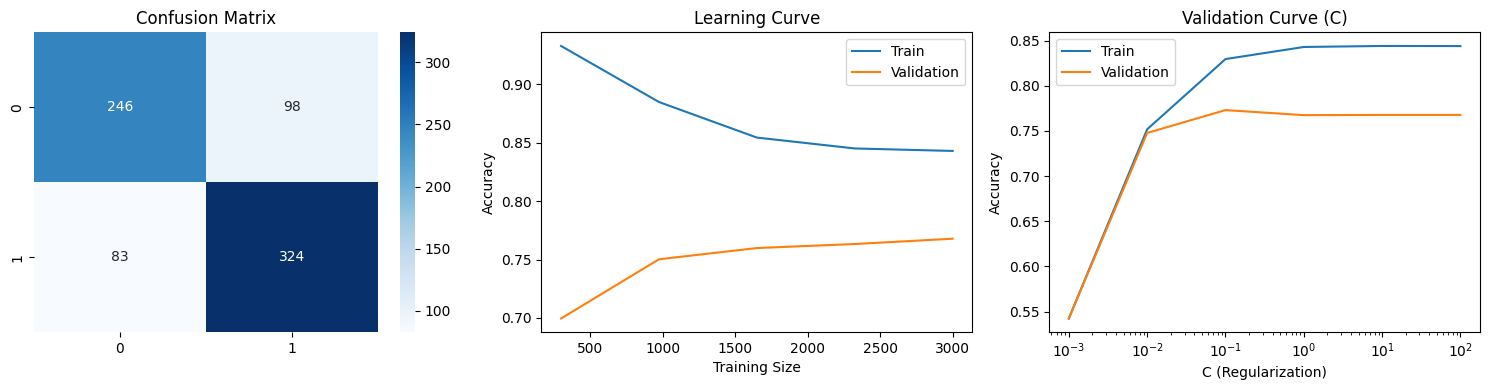


========== Analyzing Dataset: gallstones.csv ==============================
• Shape: 319 rows | 38 columns
• Target Classes: 2

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        32
           1       0.80      0.75      0.77        32

    accuracy                           0.78        64
   macro avg       0.78      0.78      0.78        64
weighted avg       0.78      0.78      0.78        64



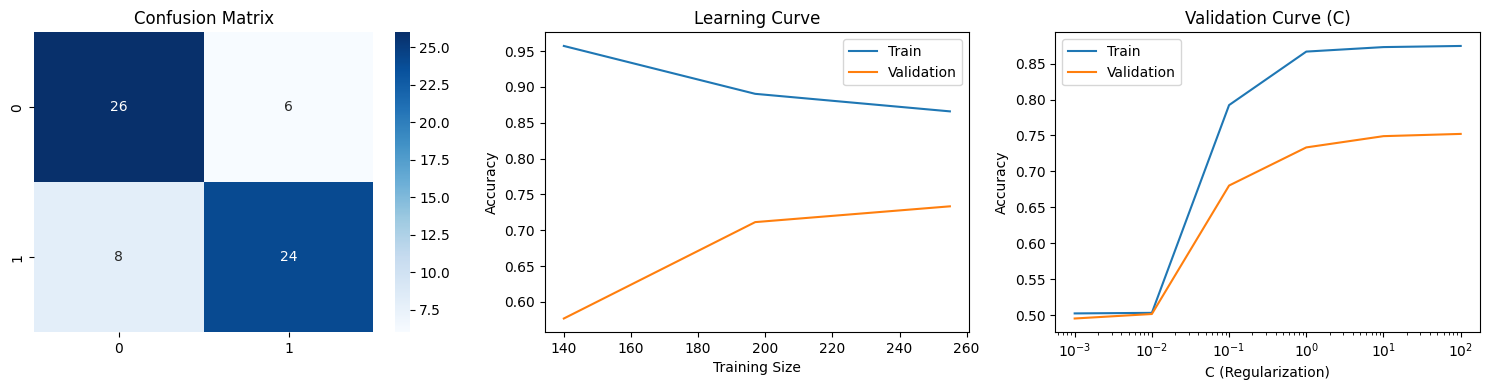


========== Analyzing Dataset: musk.csv ==============================
• Shape: 6598 rows | 135 columns
• Target Classes: 2

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1117
           1       0.83      0.75      0.79       203

    accuracy                           0.94      1320
   macro avg       0.89      0.86      0.88      1320
weighted avg       0.94      0.94      0.94      1320



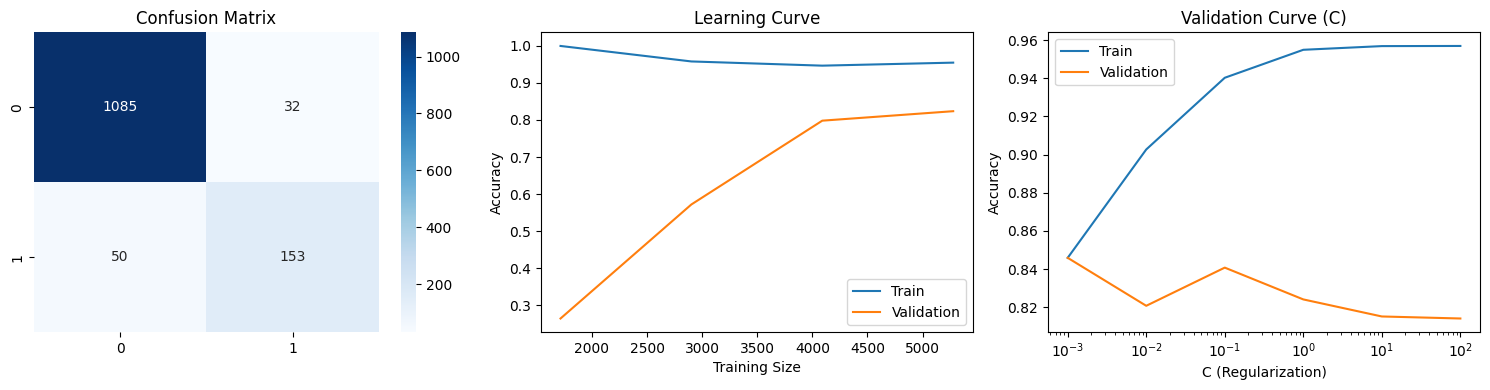


========== Analyzing Dataset: spectrometer.csv ==============================
• Shape: 531 rows | 49 columns
• Target Classes: 2

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        96
           1       1.00      0.55      0.71        11

    accuracy                           0.95       107
   macro avg       0.98      0.77      0.84       107
weighted avg       0.96      0.95      0.95       107



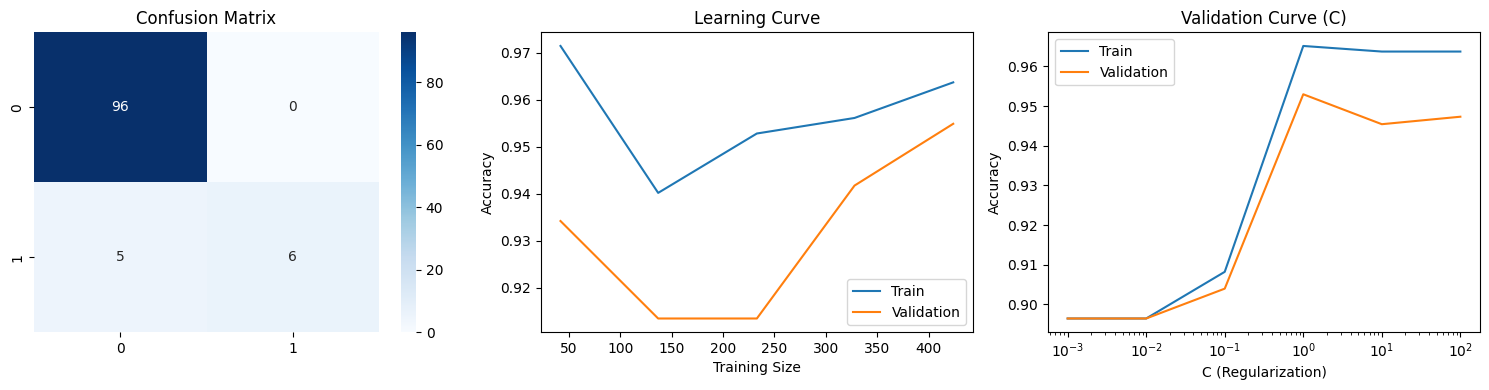


--- Final Model Performance Summary ---
         Dataset  Train Accuracy  Test Accuracy  Precision  Recall    F1  Train LogLoss  Test LogLoss   AUC
 bioresponse.csv           0.853          0.759      0.768   0.796 0.782          0.363         0.520 0.827
  gallstones.csv           0.855          0.781      0.800   0.750 0.774          0.372         0.491 0.888
        musk.csv           0.948          0.938      0.827   0.754 0.789          0.133         0.165 0.967
spectrometer.csv           0.960          0.953      1.000   0.545 0.706          0.132         0.137 0.995


In [19]:
datasets = [
    'bioresponse.csv',
    'gallstones.csv',
    'musk.csv',
    'spectrometer.csv'
]
run_analysis(datasets)

## Missing Data Algorithms
- MCAR should correspond to the MCAR setting. (function with parameter c - probability of missing data)
- MAR1 should correspond to the MAR setting and assume that the missing data
mechanism depends only on a single explanatory variable.
- MAR2 should correspond to the MAR setting and assume that the missing data
mechanism depends on all explanatory variables.
- MNAR should correspond to the MNAR setting.

desired output format:  

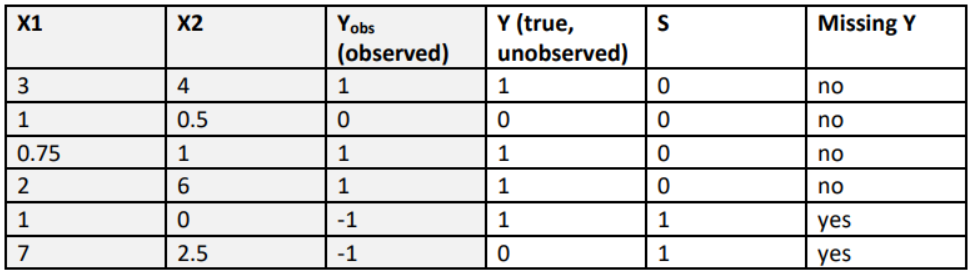

In [5]:
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_preparation import mcar, generate_missing

In [6]:
def print_dataset_header(name, shape):
    print(f"\n{'='*95}")
    print(f" DATASET: {name} | SHAPE: {shape[0]} rows x {shape[1]} cols")
    print(f"{'='*95}")
    header = f"{'Scenario':<20} | {'Actual %':<10} | {'Beta0':<12} | {'Beta_Y':<10} | {'Beta_X (Mean/Range)':<25}"
    print(header)
    print(f"{'-'*95}")

def analyze_dataset(file_path, target=0.2):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Skipping: {file_path} not found.")
        return

    # --- Standardization Step ---
    X = df.drop(columns=['class'])
    y = df['class']
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    df_std = X_scaled.copy()
    df_std['class'] = y.values 
    # ----------------------------

    print_dataset_header(file_path.split('/')[-1], df_std.shape)
    
    class_idx = df_std.columns.get_loc('class')
    n_features = df_std.shape[1] - 1

    #scenarios - name, mode, beta_x, columns_index (for MAR1), y_scale (for MNAR) 
    scenarios = [
        ("MCAR", "MCAR", None, None, None),
        ("MAR1 (Single Var)", "MAR", None, 0, 1),
        ("MAR2 (Uniform)", "MAR", None, None, 1),
        ("MAR2 (Random)", "MAR", np.random.uniform(0.1, 1.0, n_features), None, 1),
        ("MNAR (Uniform)", "MNAR", None, None, 1.5),
        ("MNAR (Random)", "MNAR", np.random.uniform(0.1, 1.0, n_features), None, 2.0),
    ]

    for name, mode, bx, c_idx, y_scale in scenarios:
        if mode == "MCAR":
            _, actual, _ = mcar(df_std, target)
            b0 = 0.0
            by = "N/A"
            bx_summary = "N/A"
        else:
            # use uniform beta_strength 0.8 when beta_x is None
            _, b0, f_betas, actual, _ = generate_missing(target, df_std, bx, c_idx, 0.8, mode, y_scale)
            
            if mode == 'MNAR':
                by = f"{f_betas[class_idx]:.2f}"
                bx_vals = np.delete(f_betas, class_idx)
            else:
                by = "N/A"
                bx_vals = f_betas
            
            bx_summary = f"{bx_vals.mean():.2f} [{bx_vals.min():.1f}, {bx_vals.max():.1f}]"
            
        print(f"{name:<20} | {actual*100:>7.2f}% | {b0:>12.4f} | {by:<10} | {bx_summary:<25}")

data_files = [
    '../data/bioresponse.csv',
    '../data/gallstones.csv',
    '../data/musk.csv',
    '../data/spectrometer.csv',
]

for file in data_files:
    analyze_dataset(file)


 DATASET: bioresponse.csv | SHAPE: 3751 rows x 1751 cols
Scenario             | Actual %   | Beta0        | Beta_Y     | Beta_X (Mean/Range)      
-----------------------------------------------------------------------------------------------
MCAR                 |   20.55% |       0.0000 | N/A        | N/A                      
MAR1 (Single Var)    |   20.21% |      -1.4944 | N/A        | 0.00 [0.0, 0.8]          
MAR2 (Uniform)       |   19.91% |    -160.3830 | N/A        | 0.80 [0.8, 0.8]          
MAR2 (Random)        |   20.02% |    -108.9495 | N/A        | 0.55 [0.1, 1.0]          
MNAR (Uniform)       |   20.05% |    -161.1061 | 1.20       | 0.80 [0.8, 0.8]          
MNAR (Random)        |   19.99% |    -112.7365 | 1.60       | 0.55 [0.1, 1.0]          

 DATASET: gallstones.csv | SHAPE: 319 rows x 38 cols
Scenario             | Actual %   | Beta0        | Beta_Y     | Beta_X (Mean/Range)      
------------------------------------------------------------------------------------